# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Shofia Ariska]
- **Email:** [CDCC220D6X1870@student.devacademy.id]
- **ID Dicoding:** [CDCC220D6X1870]

## Menentukan Pertanyaan Bisnis


- Pertanyaan 1 : Bagaimana perbandingan tingkat rata-rata penggunaan sepeda antara hari kerja dan hari libur selama periode 2011–2012 jika ditinjau secara kuantitatif, serta pendekatan strategis apa yang dapat dikembangkan dari perbedaan tersebut guna meningkatkan efisiensi distribusi sepeda dan memaksimalkan tingkat pemanfaatannya pada kedua kategori hari tersebut?

- Pertanyaan 2 : Bagaimana pola distribusi rerata jumlah penyewaan sepeda jika dianalisis berdasarkan variasi waktu per jam sepanjang periode 2011–2012, dan bagaimana pola tersebut dapat diinterpretasikan untuk merancang strategi operasional yang lebih adaptif, seperti pengaturan ketersediaan armada dan penempatan sepeda pada jam-jam dengan permintaan tinggi maupun rendah?

## Import Semua Packages/Library yang Digunakan

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [6]:
import pandas as pd
import numpy as np
hour_df = pd.read_csv('data/hour.csv')
day_df = pd.read_csv('data/day.csv')

hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset merupakan data penyewaan sepeda berbasis waktu per jam, dengan variabel utama cnt yang menunjukkan total jumlah penyewaan dalam satu jam.
- Pada sample data yang ditampilkan (jam 0–4), terlihat bahwa jumlah penyewaan relatif rendah, yang menunjukkan bahwa aktivitas penggunaan sepeda masih minim pada dini hari.
Nilai workingday = 0 dan weekday = 6 menunjukkan bahwa data berasal dari hari libur (weekend), namun tingkat penyewaan tetap rendah pada jam awal.
- Jumlah pengguna registered lebih tinggi dibandingkan casual pada setiap observasi, yang mengindikasikan bahwa layanan lebih banyak digunakan oleh pengguna tetap.
- Tidak terlihat adanya missing values pada data yang ditampilkan, sehingga dataset awal dapat dianggap bersih dan siap untuk analisis lanjutan.

### Assessing Data

In [7]:
import pandas as pd
import numpy as np

# ===============================
# FUNCTION UNTUK ANALISIS DATAFRAME
# ===============================
def explore_df(df, name):
    print(f"\n=== INFORMASI DATA: {name} ===")
    df.info()

    print(f"\n--- Tipe Data ({name}) ---")
    print(df.dtypes)

    print(f"\n--- Jumlah Missing Values ({name}) ---")
    print(df.isna().sum())

    print(f"\n--- Jumlah Data Duplikat ({name}) ---")
    print(df.duplicated().sum())

    print(f"\n--- Statistik Deskriptif ({name}) ---")
    print(df.describe())

    print(f"\n--- Sample Data ({name}) ---")
    print(df.head())


# ===============================
# MENJALANKAN ANALISIS
# ===============================
explore_df(hour_df, "hour_df")
explore_df(day_df, "day_df")


=== INFORMASI DATA: hour_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

--- Tipe Data (

**Insight:**
- Dataset hour_df terdiri dari 17.379 baris dan 17 kolom, sedangkan day_df terdiri dari 731 baris dan 16 kolom, yang menunjukkan data sudah lengkap mencakup periode waktu yang cukup panjang.
- Tidak terdapat missing values pada seluruh kolom di kedua dataset, sehingga data dapat langsung digunakan tanpa perlu penanganan data hilang.
dsn tidak ditemukan data duplikat pada kedua dataset, yang menandakan kualitas data cukup baik dan tidak memerlukan proses deduplikasi.
- Tipe data pada kolom dteday masih berupa object, sehingga perlu dilakukan konversi ke format datetime agar analisis berbasis waktu lebih optimal.
- Variabel casual dan registered menunjukkan bahwa jumlah pengguna registered jauh lebih tinggi dibanding casual, yang mengindikasikan dominasi pengguna tetap.

### Cleaning Data

In [8]:
import pandas as pd
import numpy as np

# ===============================
# KONVERSI TIPE DATA
# ===============================
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# ===============================
# KATEGORI KONDISI CUACA
# ===============================
weather_dict = {
    1: 'Cerah',
    2: 'Berawan',
    3: 'Hujan Ringan',
    4: 'Hujan Lebat'
}

hour_df['weather_label'] = hour_df['weathersit'].map(weather_dict)

# ===============================
# CEK HASIL
# ===============================
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,weather_label
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,Cerah
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,Cerah
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,Cerah
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,Cerah
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,Cerah


**Insight:**
- Kolom dteday dikonversi dari tipe data object menjadi datetime untuk mempermudah analisis berbasis waktu.
dan masih tidak terdapat missing values maupun data duplikat, sehingga tidak diperlukan proses penghapusan atau imputasi data.
- Ditambahkan kolom baru weather_label sebagai hasil transformasi dari variabel weathersit untuk mengubah kode numerik menjadi kategori yang lebih mudah dipahami (misalnya: Cerah, Berawan, dll).
-Variabel kategorikal seperti season, weathersit, dan workingday tetap dipertahankan dalam bentuk numerik namun sudah memiliki makna yang jelas untuk analisis.
- Variabel target cnt dipastikan merupakan hasil penjumlahan dari casual dan registered, sehingga tidak diperlukan transformasi tambahan.
- Format dan struktur dataset sudah konsisten serta siap digunakan untuk tahap eksplorasi data (EDA) dan analisis lanjutan.

## Exploratory Data Analysis (EDA)

### Perbandingan rata-rata penggunaan sepeda: weekday vs weekend

day_type
Hari Kerja    4584.820000
Hari Libur    4330.168831
Name: cnt, dtype: float64


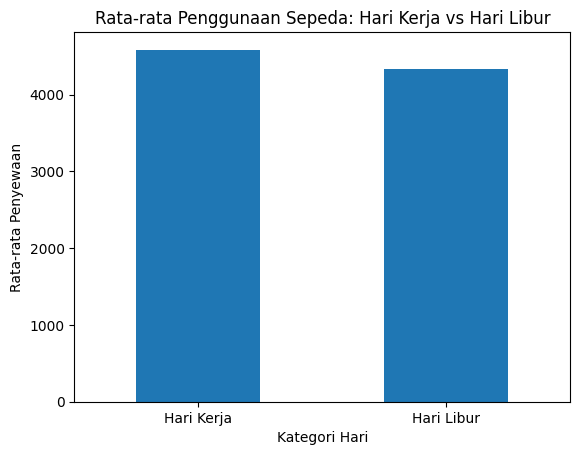

In [9]:
# Mapping workingday biar lebih jelas
day_df['day_type'] = day_df['workingday'].map({
    1: 'Hari Kerja',
    0: 'Hari Libur'
})

# Hitung rata-rata
avg_usage = day_df.groupby('day_type')['cnt'].mean().sort_values(ascending=False)
print(avg_usage)

# Visualisasi
import matplotlib.pyplot as plt

plt.figure()
avg_usage.plot(kind='bar')
plt.title('Rata-rata Penggunaan Sepeda: Hari Kerja vs Hari Libur')
plt.xlabel('Kategori Hari')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(rotation=0)
plt.show()

### Pola distribusi penyewaan per jam

hr
0    53.898072
1    33.375691
2    22.869930
3    11.727403
4     6.352941
Name: cnt, dtype: float64


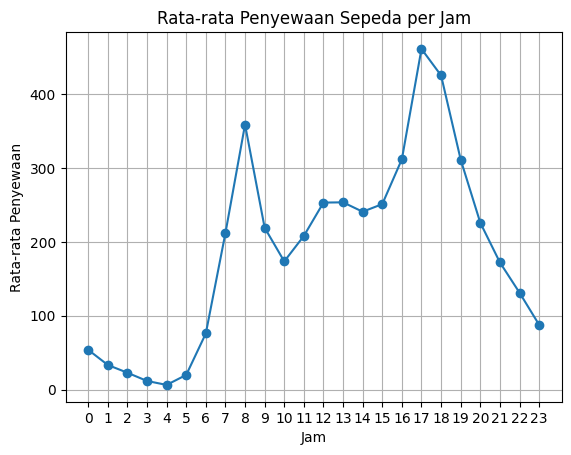

In [10]:
# Hitung rata-rata per jam
hourly_usage = hour_df.groupby('hr')['cnt'].mean()

print(hourly_usage.head())

# Visualisasi
plt.figure()
hourly_usage.plot(kind='line', marker='o')
plt.title('Rata-rata Penyewaan Sepeda per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(range(0,24))
plt.grid()
plt.show()

### Kombinasi Analisis Distribusi Jam dan Hari

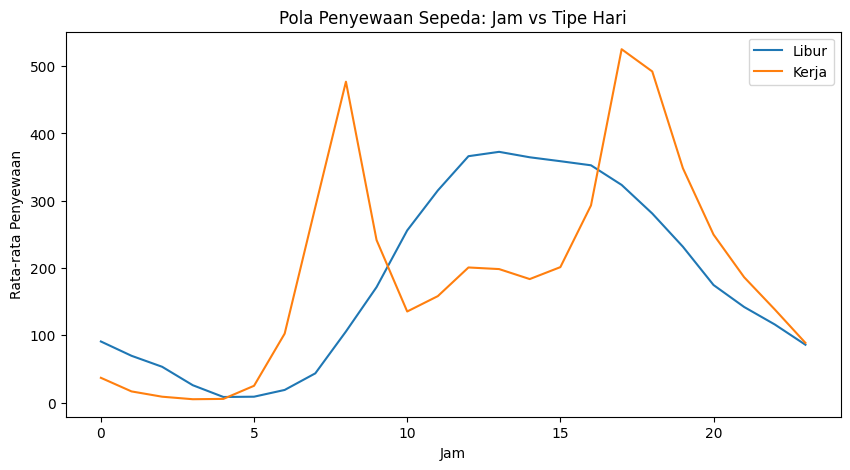

In [12]:
hour_day = hour_df.groupby(['hr', 'workingday'])['cnt'].mean().unstack()

hour_day.plot(figsize=(10,5))
plt.title('Pola Penyewaan Sepeda: Jam vs Tipe Hari')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.legend(['Libur', 'Kerja'])
plt.show()

### Insight Perbandingan rata-rata penggunaan sepeda: weekday vs weekend
- Rata-rata penyewaan pada hari kerja (4584) lebih tinggi dibandingkan hari libur (4330).
- Hal ini menunjukkan bahwa sepeda lebih sering digunakan pada hari kerja, terutama untuk aktivitas rutin seperti bekerja atau sekolah.
- selisihnya tidak terlalu besar, yang mengindikasikan bahwa penggunaan sepeda pada hari libur juga cukup tinggi.

### Insight Berdasarkan Pola distribusi penyewaan per jam
- Terdapat pola penggunaan yang jelas berdasarkan waktu, dengan dua puncak utama:
Pagi (sekitar jam 08.00)
Sore (sekitar jam 17.00–18.00)
- Penyewaan sangat rendah pada dini hari (00.00–05.00), menunjukkan minimnya aktivitas pengguna pada waktu tersebut.
- Setelah pagi hari, terjadi penurunan di siang hari sebelum meningkat kembali di sore hari.
### Insight Berdasarkan Kombinasi Analisis Distribusi Jam dan Hari
- Pada hari kerja, pola penyewaan sangat terstruktur dengan lonjakan tinggi pada pagi dan sore hari.
- Pada hari libur, pola penggunaan lebih menyebar dan tidak memiliki puncak yang terlalu tajam.
- Puncak pagi pada hari kerja jauh lebih tinggi dibandingkan hari libur, yang menunjukkan aktivitas berangkat kerja.


## Visualization & Explanatory Analysis

### Pertanyaan 1:
Analisis (Rata-rata Weekday vs Weekend)

In [15]:
import pandas as pd
import numpy as np

# Analisis rata-rata berdasarkan jenis hari
day_analysis = day_df.groupby('workingday')['cnt'].mean().sort_values(ascending=False)

day_analysis.head()

,cnt
workingday,
1,4584.820000
0,4330.168831


Visualisasi 1:

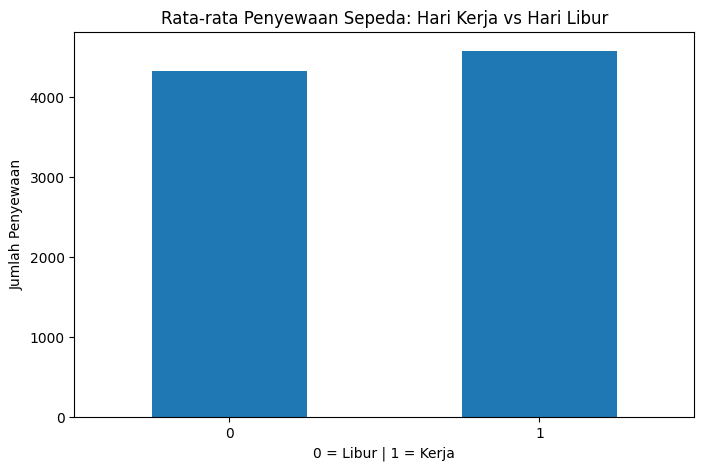

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

day_df.groupby('workingday')['cnt'].mean().plot(
    kind='bar'
)

plt.title('Rata-rata Penyewaan Sepeda: Hari Kerja vs Hari Libur')
plt.xlabel('0 = Libur | 1 = Kerja')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(rotation=0)
plt.show()

**Insight:**
- Rata-rata penyewaan sepeda pada hari kerja (4584) lebih tinggi dibandingkan hari libur (4330).
- Hal ini menunjukkan bahwa sepeda lebih sering digunakan pada hari kerja, terutama untuk aktivitas rutin seperti bekerja atau sekolah.
- Selisih antara hari kerja dan hari libur tidak terlalu besar, yang mengindikasikan bahwa penggunaan sepeda pada hari libur juga tetap cukup tinggi.
- Visualisasi bar chart memperlihatkan bahwa kedua kategori memiliki nilai yang relatif dekat, namun tetap menunjukkan dominasi pada hari kerja.
- Penggunaan sepeda pada hari libur tetap signifikan, yang menunjukkan bahwa sepeda juga dimanfaatkan untuk aktivitas rekreasi atau kebutuhan non-rutin.

### Pertanyaan 2:
Analisis (Rata-rata per Jam)

In [17]:
import pandas as pd
import numpy as np

# Analisis rata-rata penyewaan per jam
hour_analysis = hour_df.groupby('hr')['cnt'].mean().sort_values(ascending=False)

hour_analysis.head()

,cnt
hr,
17,461.452055
18,425.510989
8,359.011004
16,311.983562
19,311.523352


Visualisasi 2:

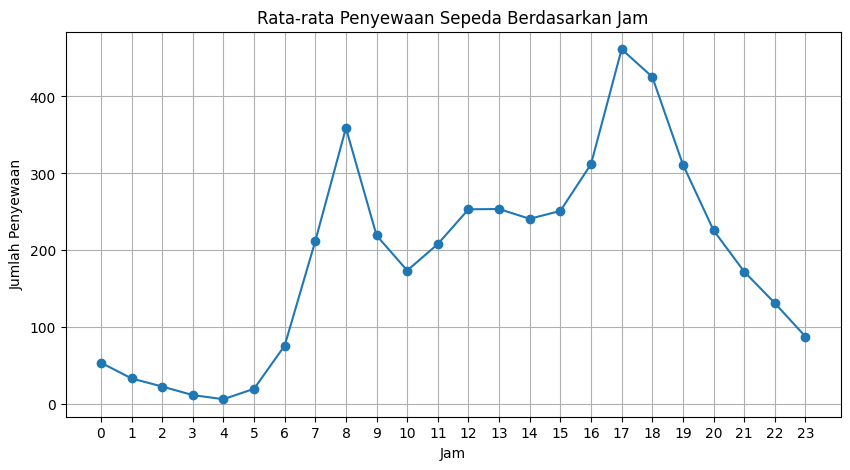

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

hour_df.groupby('hr')['cnt'].mean().plot(
    kind='line',
    marker='o'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0,24))
plt.grid()
plt.show()

**Insight:**
- Penyewaan sepeda tertinggi terjadi pada jam 17–18, diikuti oleh jam 08.
- Terdapat pola dua puncak (bimodal) yaitu pagi dan sore hari.
- Penyewaan sangat rendah pada jam 00–05, menunjukkan minimnya aktivitas pengguna.
- Pola penggunaan dipengaruhi oleh jam aktivitas manusia (rutinitas harian).
- Sepeda dominan digunakan sebagai alat transportasi (commuting), bukan hanya rekreasi.

## Analisis Lanjutan (Opsional)

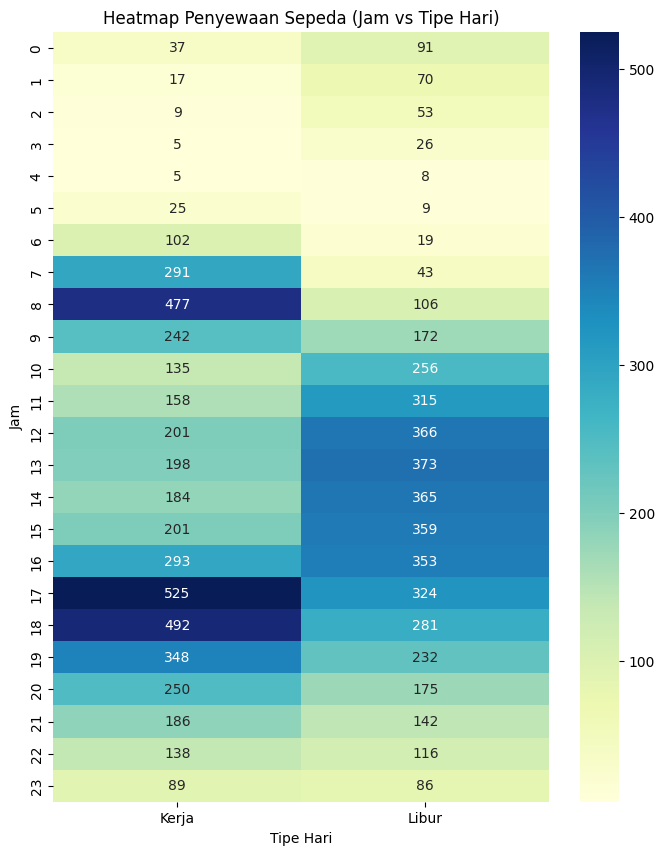

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Buat kategori hari
hour_df['day_type'] = hour_df['workingday'].map({
    1: 'Kerja',
    0: 'Libur'
})

# Pivot table: jam vs tipe hari
pivot_table = hour_df.pivot_table(
    values='cnt',
    index='hr',
    columns='day_type',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(8,10))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True, fmt='.0f')

plt.title('Heatmap Penyewaan Sepeda (Jam vs Tipe Hari)')
plt.xlabel('Tipe Hari')
plt.ylabel('Jam')
plt.show()

## Conclusion

## Conclusion

### Pertanyaan 1
Rata-rata penyewaan sepeda pada hari kerja (4584) lebih tinggi dibandingkan hari libur (4330), yang menunjukkan bahwa sepeda lebih banyak digunakan untuk aktivitas rutin seperti bekerja atau sekolah. Meskipun demikian, penggunaan pada hari libur tetap cukup tinggi, menandakan bahwa sepeda juga dimanfaatkan untuk aktivitas rekreasi.

Rekomendasi:

- Memfokuskan distribusi sepeda di area perkantoran dan pusat transportasi pada hari kerja.
- Meningkatkan ketersediaan sepeda pada hari kerja untuk mengakomodasi permintaan yang lebih tinggi.
- Mengembangkan promosi atau program khusus pada hari libur untuk meningkatkan penggunaan sepeda.

---

### Pertanyaan 2
Penyewaan sepeda menunjukkan pola bimodal dengan puncak pada jam 08.00 dan jam 17.00–18.00, serta titik tertinggi terjadi pada jam 17 (~461 penyewaan). Pola ini menunjukkan bahwa sepeda digunakan sebagai sarana transportasi harian (commuting). Sementara itu, penyewaan sangat rendah pada jam dini hari (00.00–05.00).

Rekomendasi:

- Menambah jumlah sepeda pada jam sibuk (pagi dan sore) untuk menghindari kekurangan unit.
- Melakukan maintenance dan redistribusi sepeda pada jam sepi (dini hari).
- Mengoptimalkan distribusi sepeda secara dinamis berdasarkan pola waktu penggunaan.

In [25]:
import pandas as pd
import numpy as np
import os

os.makedirs('dashboard', exist_ok=True)

In [32]:
import pandas as pd
import numpy as np
df = hour_df[['hr', 'workingday', 'cnt']]
df.to_csv('main_data.csv', index=False)

In [34]:
with open('dashboard/dashboard.py', 'w') as f:
    f.write(dashboard_code)

In [37]:
dashboard_code = """
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('main_data.csv')

st.set_page_config(layout="wide")
st.title('🚲 Bike Sharing Dashboard')

# ===============================
# SIDEBAR FILTER
# ===============================
st.sidebar.header('Filter')

hour_range = st.sidebar.slider('Pilih Jam', 0, 23, (0, 23))
day_filter = st.sidebar.selectbox('Tipe Hari', ['Semua', 'Kerja', 'Libur'])

# Filter data
filtered_df = df[(df['hr'] >= hour_range[0]) & (df['hr'] <= hour_range[1])]

if day_filter == 'Kerja':
    filtered_df = filtered_df[filtered_df['workingday'] == 1]
elif day_filter == 'Libur':
    filtered_df = filtered_df[filtered_df['workingday'] == 0]

# Mapping label
filtered_df['day_type'] = filtered_df['workingday'].map({
    1: 'Kerja',
    0: 'Libur'
})

# ===============================
# METRICS
# ===============================
col1, col2, col3 = st.columns(3)

col1.metric("Total", int(filtered_df['cnt'].sum()))
col2.metric("Rata-rata", round(filtered_df['cnt'].mean(), 2))
col3.metric("Peak Hour", int(filtered_df.groupby('hr')['cnt'].mean().idxmax()))

# ===============================
# GRAFIK JAM
# ===============================
st.subheader('📈 Pola Penyewaan per Jam')

hour_data = filtered_df.groupby('hr')['cnt'].mean()

fig, ax = plt.subplots(figsize=(10,4))
hour_data.plot(marker='o', ax=ax)
ax.set_xlabel('Jam')
ax.set_ylabel('Jumlah')
ax.grid()
st.pyplot(fig)

# ===============================
# GRAFIK HARI
# ===============================
st.subheader('📊 Hari Kerja vs Libur')

day_data = filtered_df.groupby('day_type')['cnt'].mean()

fig2, ax2 = plt.subplots()
sns.barplot(x=day_data.index, y=day_data.values, ax=ax2)
st.pyplot(fig2)

# ===============================
# HEATMAP
# ===============================
st.subheader('Heatmap Jam vs Hari')

pivot = filtered_df.pivot_table(
    values='cnt',
    index='hr',
    columns='day_type',
    aggfunc='mean'
)

fig3, ax3 = plt.subplots(figsize=(6,8))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.0f', ax=ax3)
st.pyplot(fig3)
"""